# Feature Engineering Pipeline (Robust & No-Leakage)

Questo notebook implementa una pipeline completa di Feature Engineering per il dataset GUIDE (Microsoft Incident Prediction).

**Obiettivo:** Trasformare i dati grezzi (livello Evidence) in un dataset pronto per il Machine Learning (livello Incident), mantenendo una rigorosa separazione tra Train e Test per evitare Data Leakage.

**Step Principali:**
1.  **Caricamento:** Importazione di `GUIDE_Train` e `GUIDE_Test`.
2.  **Target Engineering:** Definizione della variabile target (Binary: TruePositive vs Altri).
3.  **Evidence-Level Engineering:**
    *   Encoding Temporale
    *   *Smoothed Risk Score* (Calcolato su Train, applicato a Test)
    *   *Frequency Encoding* (Calcolato su Train, applicato a Test)
    *   Parsing Tecniche MITRE
4.  **Incident-Level Aggregation:** Aggregazione delle evidenze per ottenere una riga per Incidente.
5.  **Visual Analysis & Undersampling:** Analisi delle correlazioni e bilanciamento delle classi.
6.  **Export:** Salvataggio dei dataset processati.

In [17]:
import pandas as pd
import numpy as np
import os
import pickle
from collections import Counter
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.utils import resample
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configurazioni
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
%matplotlib inline
sns.set_style('whitegrid')

# Percorsi
DATA_DIR = '../data'
OUTPUT_DIR = '../data/processed_final'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Setup completato. Output directory:", OUTPUT_DIR)

Setup completato. Output directory: ../data/processed_final


## 1. Caricamento Dati

In [18]:
print("Caricamento dataset...")
# Carichiamo i dataset originali
train_df = pd.read_csv(os.path.join(DATA_DIR, 'GUIDE_Train.csv'))
test_df = pd.read_csv(os.path.join(DATA_DIR, 'GUIDE_Test.csv'))

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

Caricamento dataset...
Train shape: (9516837, 45)
Test shape: (4147992, 46)


## 2. Pulizia e Preparazione Iniziale
Rimuoviamo le righe senza target nel training set e definiamo la variabile target binaria.

In [19]:
# Rimuovi righe senza IncidentGrade nel Train (se presenti)
train_df = train_df.dropna(subset=['IncidentGrade'])

# Definizione Target Binario: 1 se TruePositive, 0 altrimenti
train_df['Target'] = (train_df['IncidentGrade'] == 'TruePositive').astype(int)

# Per il Test set, se IncidentGrade è presente lo usiamo per validazione, altrimenti sarà NaN
if 'IncidentGrade' in test_df.columns:
    test_df['Target'] = (test_df['IncidentGrade'] == 'TruePositive').astype(int)
else:
    test_df['Target'] = np.nan

print("Target distribution (Train):")
print(train_df['Target'].value_counts(normalize=True))

# --- SPLIT A LIVELLO INCIDENT PRIMA DEL TARGET ENCODING ---
# Questo previene data leakage nel validation set
from sklearn.model_selection import train_test_split

# Ottieni lista unica di IncidentId con il loro target (a livello incident)
incident_targets = train_df.groupby('IncidentId')['Target'].first().reset_index()

# Split stratificato degli IncidentId (90% train, 10% validation)
train_incidents, val_incidents = train_test_split(
    incident_targets['IncidentId'],
    test_size=0.1,
    random_state=42,
    stratify=incident_targets['Target']
)

# Separa i dataframe a livello evidence
train_fold = train_df[train_df['IncidentId'].isin(train_incidents)].copy()
val_fold = train_df[train_df['IncidentId'].isin(val_incidents)].copy()

print(f"\n--- Split Anti-Leakage ---")
print(f"Train Incidents: {len(train_incidents)} ({len(train_fold)} evidences)")
print(f"Val Incidents:   {len(val_incidents)} ({len(val_fold)} evidences)")

Target distribution (Train):
Target
0    0.648966
1    0.351034
Name: proportion, dtype: float64

--- Split Anti-Leakage ---
Train Incidents: 404010 (8476186 evidences)
Val Incidents:   44891 (989311 evidences)


## 3. Feature Engineering (Evidence Level)

In questa fase creiamo nuove feature per ogni evidenza. 
**Regola d'oro:** Qualsiasi statistica globale (medie, frequenze) deve essere calcolata SOLO sul Train e poi applicata (mappata) sul Test.

### 3.1 Features Temporali

In [20]:
def extract_time_features(df):
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df['Hour'] = df['Timestamp'].dt.hour
    df['DayOfWeek'] = df['Timestamp'].dt.dayofweek
    df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)
    return df

train_fold = extract_time_features(train_fold)
val_fold = extract_time_features(val_fold)
test_df = extract_time_features(test_df)
print("Features temporali estratte.")

Features temporali estratte.


### 3.2 Smoothed Risk Encoding (Target Encoding)
Calcoliamo la probabilità che un certo `AlertTitle` sia un True Positive. Usiamo lo *smoothing* per evitare overfitting su categorie rare.
Calcoliamo la mappa su `train_df` e la applichiamo a entrambi.

In [21]:
# Parametri per smoothing bayesiano
alpha = 5  # Prior weight
global_mean = train_fold['Target'].mean()  # Calcolato SOLO su train_fold!

# Calcolo statistiche SOLO su TRAIN_FOLD (no leakage)
stats = train_fold.groupby('AlertTitle')['Target'].agg(['count', 'mean'])
smoothed_score = (stats['count'] * stats['mean'] + alpha * global_mean) / (stats['count'] + alpha)
risk_map = smoothed_score.to_dict()

# Applicazione a tutti i dataset
train_fold['AlertRisk'] = train_fold['AlertTitle'].map(risk_map).fillna(global_mean)
val_fold['AlertRisk'] = val_fold['AlertTitle'].map(risk_map).fillna(global_mean)
test_df['AlertRisk'] = test_df['AlertTitle'].map(risk_map).fillna(global_mean)

print("Smoothed Risk calcolato su train_fold e applicato a train/val/test.")

Smoothed Risk calcolato su train_fold e applicato a train/val/test.


### 3.3 Frequency Encoding & GeoLocation
Codifichiamo variabili categoriche ad alta cardinalità con la loro frequenza nel training set.

In [22]:
# Creazione feature combinata Geografica
for df in [train_fold, val_fold, test_df]:
    df['GeoLoc'] = df['CountryCode'].astype(str) + '_' + df['State'].astype(str) + '_' + df['City'].astype(str)

# Colonne da codificare in frequenza
freq_cols = ['GeoLoc', 'DeviceName', 'FileName', 'IpAddress', 'Url']

for col in freq_cols:
    # Calcola frequenza SOLO su TRAIN_FOLD (no leakage)
    freq_map = train_fold[col].value_counts(normalize=True).to_dict()
    
    # Applica a tutti (con 0 per valori nuovi)
    train_fold[f'{col}_Freq'] = train_fold[col].map(freq_map).fillna(0)
    val_fold[f'{col}_Freq'] = val_fold[col].map(freq_map).fillna(0)
    test_df[f'{col}_Freq'] = test_df[col].map(freq_map).fillna(0)

print(f"Frequency encoding applicato su: {freq_cols}")

Frequency encoding applicato su: ['GeoLoc', 'DeviceName', 'FileName', 'IpAddress', 'Url']


### 3.4 MITRE Techniques Processing
Estraiamo le tecniche più comuni (Top 20) e creiamo flag binari.

In [23]:
# Parsing della colonna (stringa separata da ;)
def parse_techniques(series):
    return series.fillna('').astype(str).apply(lambda x: x.split(';') if x else [])

train_techs = parse_techniques(train_fold['MitreTechniques'])
val_techs = parse_techniques(val_fold['MitreTechniques'])
test_techs = parse_techniques(test_df['MitreTechniques'])

# Identifica le Top 20 tecniche SOLO nel TRAIN_FOLD (no leakage)
all_train_techs = [t for sublist in train_techs for t in sublist if t]
top_techs = [t for t, count in Counter(all_train_techs).most_common(20)]  # FIX: era t[0]

print("Top MITRE Techniques:", top_techs)

# One-Hot Encoding manuale per le top tecniche
for tech in top_techs:
    clean_tech_name = tech.replace('.', '_')  # Pulisci nome colonna
    train_fold[f'Mitre_{clean_tech_name}'] = train_fold['MitreTechniques'].apply(lambda x: 1 if pd.notna(x) and tech in str(x) else 0)
    val_fold[f'Mitre_{clean_tech_name}'] = val_fold['MitreTechniques'].apply(lambda x: 1 if pd.notna(x) and tech in str(x) else 0)
    test_df[f'Mitre_{clean_tech_name}'] = test_df['MitreTechniques'].apply(lambda x: 1 if pd.notna(x) and tech in str(x) else 0)

# Conteggio totale tecniche
train_fold['Mitre_Count'] = train_techs.apply(len)
val_fold['Mitre_Count'] = val_techs.apply(len)
test_df['Mitre_Count'] = test_techs.apply(len)

Top MITRE Techniques: ['T1078', 'T1078.004', 'T1566.002', 'T1566', 'T1110', 'T1133', 'T1566.001', 'T1110.003', 'T1110.001', 'T1071', 'T1087', 'T1046', 'T1087.002', 'T1098', 'T1190', 'T1210', 'T1559', 'T1059.005', 'T1568', 'T1008']


## 4. Aggregazione a Livello di Incidente
Ora comprimiamo le righe. Ogni `IncidentId` avrà una sola riga nel dataset finale. 
Le features delle evidenze verranno aggregate (media, somma, max, ecc.).

In [24]:
def aggregate_incidents(df):
    # Definiamo il dizionario di aggregazione
    agg_dict = {
        'Target': 'max',  # Se almeno una evidenza è TP, l'incidente è TP
        'AlertId': 'nunique',  # Numero di alert unici
        'Id': 'count',  # Numero totale di evidenze
        'AlertRisk': ['mean', 'max'],
        'Hour': ['mean', 'std'],
        'IsWeekend': 'mean',  # % di evidenze nel weekend
        'Mitre_Count': 'sum',
        # Rimosso OrgId per evitare overfitting su ID categorici
    }
    
    # Aggiungi aggregazioni per colonne frequenza
    for col in freq_cols:
        agg_dict[f'{col}_Freq'] = ['mean', 'max']
        
    # Aggiungi aggregazioni per colonne MITRE (max = presenza nell'incidente)
    mitre_cols = [c for c in df.columns if c.startswith('Mitre_') and c != 'Mitre_Count']
    for col in mitre_cols:
        agg_dict[col] = 'max'

    # Esegui GroupBy
    print("Esecuzione aggregazione...")
    df_agg = df.groupby('IncidentId').agg(agg_dict)
    
    # Appiattisci i nomi delle colonne (es. AlertRisk_mean)
    df_agg.columns = ['_'.join(col).strip() for col in df_agg.columns.values]
    df_agg.reset_index(inplace=True)
    
    # Rinomina alcune colonne chiave
    df_agg.rename(columns={'Target_max': 'Target', 'Id_count': 'EvidenceCount', 'AlertId_nunique': 'AlertCount'}, inplace=True)
    
    return df_agg

print("Aggregazione Train Fold...")
train_agg = aggregate_incidents(train_fold)

print("Aggregazione Validation Fold...")
val_agg = aggregate_incidents(val_fold)

print("Aggregazione Test Set...")
test_agg = aggregate_incidents(test_df)

print(f"\nTrain Aggregated Shape: {train_agg.shape}")
print(f"Val Aggregated Shape:   {val_agg.shape}")
print(f"Test Aggregated Shape:  {test_agg.shape}")

Aggregazione Train Fold...
Esecuzione aggregazione...
Aggregazione Validation Fold...
Esecuzione aggregazione...
Aggregazione Test Set...
Esecuzione aggregazione...

Train Aggregated Shape: (404010, 40)
Val Aggregated Shape:   (44891, 40)
Test Aggregated Shape:  (236267, 40)


## 5. Visual Analysis & Undersampling
Verifichiamo l'utilità delle feature e bilanciamo le classi.

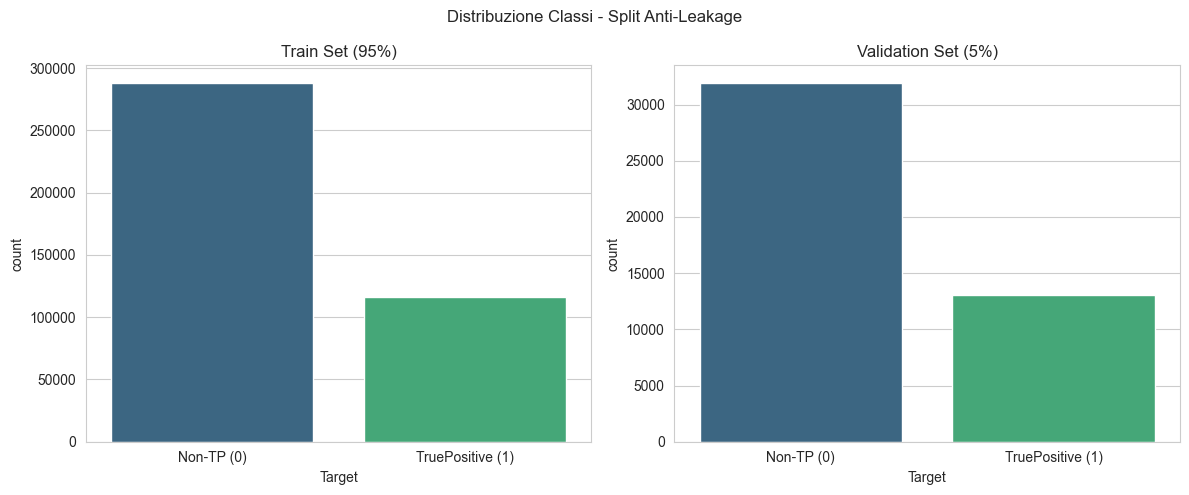

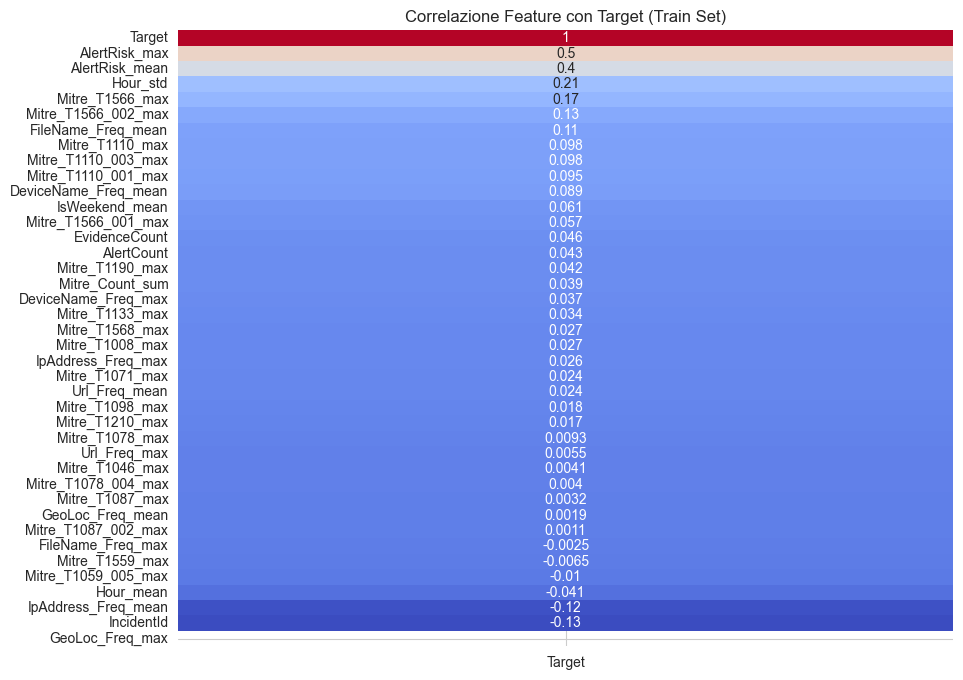

Top 10 Feature Correlate positivamente:
Target                 1.000000
AlertRisk_max          0.499828
AlertRisk_mean         0.400485
Hour_std               0.207429
Mitre_T1566_max        0.172475
Mitre_T1566_002_max    0.129004
FileName_Freq_mean     0.105263
Mitre_T1110_max        0.097950
Mitre_T1110_003_max    0.097540
Mitre_T1110_001_max    0.095380
Name: Target, dtype: float64


In [25]:
# Analisi Distribuzione Classi
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x='Target', data=train_agg, palette='viridis', ax=axes[0])
axes[0].set_title('Train Set (95%)')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Non-TP (0)', 'TruePositive (1)'])

sns.countplot(x='Target', data=val_agg, palette='viridis', ax=axes[1])
axes[1].set_title('Validation Set (5%)')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Non-TP (0)', 'TruePositive (1)'])

plt.suptitle('Distribuzione Classi - Split Anti-Leakage')
plt.tight_layout()
plt.show()

# Analisi Correlazione con il Target (solo train)
numeric_cols = train_agg.select_dtypes(include=[np.number]).columns
correlation = train_agg[numeric_cols].corr()['Target'].sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation.to_frame(), annot=True, cmap='coolwarm', cbar=False)
plt.title('Correlazione Feature con Target (Train Set)')
plt.show()

print("Top 10 Feature Correlate positivamente:")
print(correlation.head(10))

In [26]:
# --- UNDERSAMPLING (su Train e Validation) ---
print("Esecuzione Undersampling della classe maggioritaria...")

def undersample_dataset(df, name="Dataset"):
    """Applica undersampling per bilanciare le classi."""
    df_majority = df[df.Target == 0]
    df_minority = df[df.Target == 1]
    
    print(f"\n{name}:")
    print(f"  Classe Maggioritaria (0): {len(df_majority)}")
    print(f"  Classe Minoritaria (1): {len(df_minority)}")
    
    # Undersample della maggioritaria
    df_majority_downsampled = resample(df_majority, 
                                       replace=False,
                                       n_samples=len(df_minority),
                                       random_state=42) 
    
    # Combinazione e shuffle
    df_balanced = pd.concat([df_majority_downsampled, df_minority])
    df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)
    
    print(f"  Bilanciato: {df_balanced.shape[0]} samples")
    return df_balanced

# Applica undersampling a entrambi
train_balanced = undersample_dataset(train_agg, "Train Set")
val_balanced = undersample_dataset(val_agg, "Validation Set")

print("\n--- Riepilogo Finale ---")
print(f"Train Bilanciato: {train_balanced['Target'].value_counts().to_dict()}")
print(f"Val Bilanciato:   {val_balanced['Target'].value_counts().to_dict()}")

Esecuzione Undersampling della classe maggioritaria...

Train Set:
  Classe Maggioritaria (0): 287678
  Classe Minoritaria (1): 116332
  Bilanciato: 232664 samples

Validation Set:
  Classe Maggioritaria (0): 31880
  Classe Minoritaria (1): 13011
  Bilanciato: 26022 samples

--- Riepilogo Finale ---
Train Bilanciato: {0: 116332, 1: 116332}
Val Bilanciato:   {0: 13011, 1: 13011}


## 6. Salvataggio Output
Salviamo i file pronti per l'addestramento dei modelli. 
**Nota:** Salviamo sia la versione sbilanciata (`train_final.csv`) che quella bilanciata (`train_balanced.csv`) per poter sperimentare.

In [27]:
# Fill NaN generati dall'aggregazione (es. std su un solo elemento)
train_agg.fillna(0, inplace=True)
train_balanced.fillna(0, inplace=True)
val_agg.fillna(0, inplace=True)
val_balanced.fillna(0, inplace=True)
test_agg.fillna(0, inplace=True)

# Salvataggio
train_agg.to_csv(os.path.join(OUTPUT_DIR, 'train_final_imbalanced.csv'), index=False)
train_balanced.to_csv(os.path.join(OUTPUT_DIR, 'train_final_balanced.csv'), index=False)
val_agg.to_csv(os.path.join(OUTPUT_DIR, 'val_final_imbalanced.csv'), index=False)
val_balanced.to_csv(os.path.join(OUTPUT_DIR, 'val_final.csv'), index=False)  # Validation bilanciato
test_agg.to_csv(os.path.join(OUTPUT_DIR, 'test_final.csv'), index=False)

# Salva anche versione combinata train+val per compatibilità (opzionale)
train_full = pd.concat([train_agg, val_agg], ignore_index=True)
train_full.to_csv(os.path.join(OUTPUT_DIR, 'train_final.csv'), index=False)

# Salvataggio delle mappature per inferenza futura
mappings = {
    'risk_map': risk_map,
    'top_techs': top_techs,
    'global_mean': global_mean,
    'freq_cols': freq_cols
}
with open(os.path.join(OUTPUT_DIR, 'feature_mappings.pkl'), 'wb') as f:
    pickle.dump(mappings, f)

print("Dataset salvati in", OUTPUT_DIR)
print("- train_final_imbalanced.csv (90% train, sbilanciato)")
print("- train_final_balanced.csv (90% train, undersampled)")
print("- val_final_imbalanced.csv (10% validation, sbilanciato)")
print("- val_final.csv (10% validation, undersampled)")
print("- test_final.csv (GUIDE_Test)")
print("- train_final.csv (train+val combinati, sbilanciato)")
print("- feature_mappings.pkl")

Dataset salvati in ../data/processed_final
- train_final_imbalanced.csv (90% train, sbilanciato)
- train_final_balanced.csv (90% train, undersampled)
- val_final_imbalanced.csv (10% validation, sbilanciato)
- val_final.csv (10% validation, undersampled)
- test_final.csv (GUIDE_Test)
- train_final.csv (train+val combinati, sbilanciato)
- feature_mappings.pkl
